In [11]:
import numpy as np, cv2
import matplotlib.pyplot as plt

행렬의 곱

In [ ]:
src1 = np.array([1, 2, 3, 1, 2, 3], np.float32).reshape(2, 3)
src2 = np.array([1, 2, 3, 4, 5, 6], np.float32).reshape(3, 2)
src3 = np.array([1, 2, 3, 4, 5, 6], np.float32).reshape(2, 3)
alpha, beta = 1.0, 1.0

dst1 = cv2.gemm(src1, src2, alpha, None, beta) # src의 크기를 내적 계산을 위해 맞춘 것
dst2 = cv2.gemm(src1, src3, alpha, None, beta, flags=cv2.GEMM_1_T) # 좌측을 전치 시켜서 맞춘 것

print(dst1)
print(dst2)


[[22. 28.]
 [22. 28.]]
[[ 5.  7.  9.]
 [10. 14. 18.]
 [15. 21. 27.]]


회전변환

pts1[0] = [250.  30.], pts2[0] = [224.66255  113.695816]
pts1[1] = [400.  70.], pts2[1] = [351.93564 202.58655]
pts1[2] = [350. 250.], pts2[2] = [243.38737 354.63022]
pts1[3] = [150. 200.], pts2[3] = [ 72.54986 239.24155]


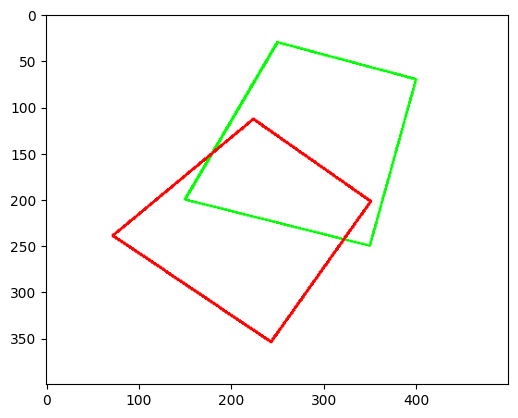

In [14]:
theta = 20 * np.pi / 180
rot_mat = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]   ], np.float32)

pts1 = np.array([(250, 30), (400, 70), (350, 250), (150, 200)], np.float32)
pts2 = cv2.gemm(pts1, rot_mat, 1, None, 1, flags=cv2.GEMM_2_T)

for i, (pt1, pt2) in enumerate(zip(pts1, pts2)):
    print("pts1[%d] = %s, pts2[%d] = %s" % (i, pt1, i, pt2))

image = np.full((400, 500, 3), 255,np.uint8)
cv2.polylines(image, [np.int32(pts1)], True, (0, 255, 0), 2)
cv2.polylines(image, [np.int32(pts2)], True, (255, 0, 0), 2)

plt.imshow(image)

역행렬과 연립방정식 풀이

In [15]:
data = [3, 0, 6, -3, 4, 2, -5, -1, 9]
m1 = np.array(data, np.float32).reshape(3, 3)
m2 = np.array([36, 10, 28], np.float32)

ret, inv = cv2.invert(m1, cv2.DECOMP_LU)

if ret:
    dst1 = inv.dot(m2)
    dst2 = cv2.gemm(inv, m2, 1, None, 1)
    _, dst3 = cv2.solve(m1, m2, cv2.DECOMP_LU)

    titles = ['inv', 'dst1', 'dst2', 'dst3']
    for title in titles:
        print("%s = \n%s \n" % (title, eval(title)))
else:
    print("역행렬이 존재하지 않습니다.")

inv = 
[[ 0.15079366 -0.02380952 -0.0952381 ]
 [ 0.06746032  0.22619048 -0.0952381 ]
 [ 0.09126984  0.01190476  0.04761905]] 

dst1 = 
[2.5238097 2.0238097 4.7380953] 

dst2 = 
[[2.5238097]
 [2.0238097]
 [4.7380953]] 

dst3 = 
[[2.5238094]
 [2.0238094]
 [4.7380953]] 

